In [2]:
# ===========================
# Import Required Libraries
# ===========================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [51]:
# ===========================
# Load Dataset
# ===========================

from pathlib import Path

# Project root (url_detection folder)
BASE_DIR = Path.cwd().parent

# Dataset path
DATASET_PATH = BASE_DIR / "datasets" / "raw" / "phishing_urls.csv"

print("Dataset Path:")
print(DATASET_PATH)

# Load dataset
df = pd.read_csv(r"C:\Users\nmaml\OneDrive\Desktop\CyberShield-AI\url_detection\datasets\raw\Dataset___URL!.csv")

print("\n✅ Dataset Loaded Successfully!")

print(f"\nDataset Shape: {df.shape}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Path:
c:\Users\nmaml\OneDrive\Desktop\CyberShield-AI\url_detection\datasets\raw\phishing_urls.csv

✅ Dataset Loaded Successfully!

Dataset Shape: (116600, 26)

Column Names:
['url', 'url_len', 'dom', 'dom_len', 'is_ip', 'tld', 'tld_len', 'subdom_cnt', 'letter_cnt', 'digit_cnt', 'special_cnt', 'eq_cnt', 'qm_cnt', 'amp_cnt', 'dot_cnt', 'dash_cnt', 'under_cnt', 'letter_ratio', 'digit_ratio', 'spec_ratio', 'is_https', 'slash_cnt', 'entropy', 'path_len', 'query_len', 'label']

First 5 Rows:


,url,url_len,dom,dom_len,is_ip,tld,tld_len,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,24,rmit.edu.au,11,0,edu.au,6,1,17,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,26,latrobe.edu.au,14,0,edu.au,6,1,19,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,23,cqu.edu.au,10,0,edu.au,6,1,16,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,http://bond.edu.au/,19,bond.edu.au,11,0,edu.au,6,0,13,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,http://www.csu.edu.au/,22,csu.edu.au,10,0,edu.au,6,1,15,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 116600 entries, 0 to 116599
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   url           116600 non-null  str    
 1   url_len       116600 non-null  int64  
 2   dom           116600 non-null  str    
 3   dom_len       116600 non-null  int64  
 4   is_ip         116600 non-null  int64  
 5   tld           116586 non-null  str    
 6   tld_len       116600 non-null  int64  
 7   subdom_cnt    116600 non-null  int64  
 8   letter_cnt    116600 non-null  int64  
 9   digit_cnt     116600 non-null  int64  
 10  special_cnt   116600 non-null  int64  
 11  eq_cnt        116600 non-null  int64  
 12  qm_cnt        116600 non-null  int64  
 13  amp_cnt       116600 non-null  int64  
 14  dot_cnt       116600 non-null  int64  
 15  dash_cnt      116600 non-null  int64  
 16  under_cnt     116600 non-null  int64  
 17  letter_ratio  116600 non-null  float64
 18  digit_ratio   1

In [53]:
# ==========================================
# Check Missing Values
# ==========================================

missing = df.isnull().sum()

missing = missing[missing > 0]

print("=" * 50)
print("Missing Values")
print("=" * 50)

if len(missing) == 0:
    print("No Missing Values Found ✅")
else:
    print(missing.sort_values(ascending=False))

Missing Values
tld    14
dtype: int64


In [54]:
# ==========================================
# Check Duplicate Rows
# ==========================================

duplicates = df.duplicated().sum()

print("=" * 50)
print("Duplicate Rows")
print("=" * 50)

print("Duplicates :", duplicates)

Duplicate Rows
Duplicates : 1369


In [55]:
# ==========================================
# Remove Duplicate Rows
# ==========================================

print("=" * 50)
print("Dataset Before Removing Duplicates")
print("=" * 50)

print(df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("\n" + "=" * 50)
print("Dataset After Removing Duplicates")
print("=" * 50)

print(df.shape)

print("\nDuplicates Remaining :", df.duplicated().sum())

Dataset Before Removing Duplicates
(116600, 26)

Dataset After Removing Duplicates
(115231, 26)

Duplicates Remaining : 0


In [56]:
# ==========================================
# Prepare Features & Target
# ==========================================

X = df.drop(columns=[
    "url",
    "dom",
    "tld",
    "label"
])

y = df["label"]

print("=" * 50)
print("Features Prepared")
print("=" * 50)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

Features Prepared
X Shape : (115231, 22)
y Shape : (115231,)


In [57]:
# ==========================================
# Check Target Distribution
# ==========================================

print("=" * 50)
print("Target Distribution")
print("=" * 50)

print(y.value_counts())

print("\nPercentage:")

print((y.value_counts(normalize=True) * 100).round(2))

Target Distribution
label
0    98641
1    16590
Name: count, dtype: int64

Percentage:
label
0    85.6
1    14.4
Name: proportion, dtype: float64


In [59]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 50)
print("Train-Test Split Completed")
print("=" * 50)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

print("\nTraining Label Distribution")
print(y_train.value_counts())

print("\nTesting Label Distribution")
print(y_test.value_counts())

Train-Test Split Completed
Training Samples : (92184, 22)
Testing Samples  : (23047, 22)

Training Label Distribution
label
0    78912
1    13272
Name: count, dtype: int64

Testing Label Distribution
label
0    19729
1     3318
Name: count, dtype: int64


In [61]:
# ==========================================
# Apply SMOTE
# ==========================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

print("=" * 50)
print("SMOTE Applied Successfully")
print("=" * 50)

print("Training Samples :", X_train.shape)

print("\nTarget Distribution After SMOTE")
print(y_train.value_counts())

SMOTE Applied Successfully
Training Samples : (157824, 22)

Target Distribution After SMOTE
label
0    78912
1    78912
Name: count, dtype: int64


In [62]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [63]:
# ==========================================
# Initialize Models
# ==========================================

models = {
    
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_estimators=300,
        tree_method="hist",
        n_jobs=-1
    )
}

In [64]:
# ==========================================
# Train & Compare Models
# ==========================================

results = []

for name, model in models.items():

    print("=" * 60)
    print(f"Training {name}...")
    print("=" * 60)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print("\nTraining Completed Successfully!\n")

display(results_df)

Training Logistic Regression...
Training Random Forest...
Training XGBoost...

Training Completed Successfully!



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.981516,0.935018,0.936709,0.935863,0.993307
1,Random Forest,0.978349,0.918373,0.932489,0.925378,0.991774
2,Logistic Regression,0.934352,0.717522,0.897227,0.797375,0.975016


In [65]:
best_model = models["XGBoost"]

In [66]:
# ==========================================
# Predictions
# ==========================================

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

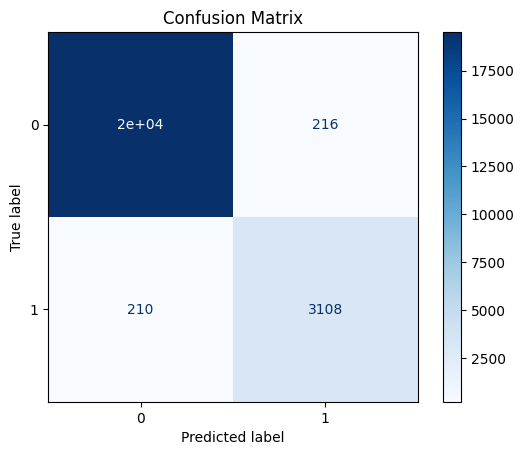

In [67]:
# ==========================================
# Confusion Matrix
# ==========================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [68]:
# ==========================================
# Classification Report
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19729
           1       0.94      0.94      0.94      3318

    accuracy                           0.98     23047
   macro avg       0.96      0.96      0.96     23047
weighted avg       0.98      0.98      0.98     23047



         Feature  Importance
15   digit_ratio    0.453651
17      is_https    0.215522
4     subdom_cnt    0.053320
11       dot_cnt    0.050413
3        tld_len    0.024821
20      path_len    0.024582
19       entropy    0.022401
1        dom_len    0.020873
18     slash_cnt    0.020610
7    special_cnt    0.019126
12      dash_cnt    0.017585
6      digit_cnt    0.010578
21     query_len    0.009952
16    spec_ratio    0.009628
8         eq_cnt    0.009614
0        url_len    0.009481
5     letter_cnt    0.008907
13     under_cnt    0.007591
14  letter_ratio    0.005880
9         qm_cnt    0.003429
10       amp_cnt    0.001994
2          is_ip    0.000041


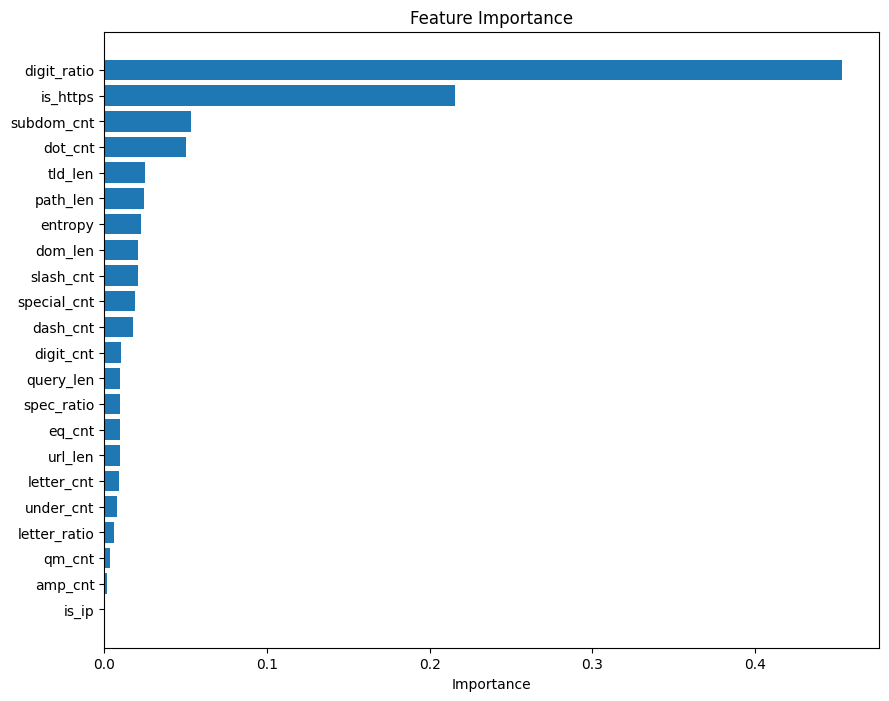

In [69]:
# ==========================================
# Feature Importance
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(10,8))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.show()

In [73]:
import joblib

model = joblib.load("url_phishing_model.pkl")

print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


In [74]:
# ==========================================
# Save XGBoost Model
# ==========================================

import os
import joblib

# Create the models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the trained model
joblib.dump(best_model, "models/xgboost_url_detector.pkl")

print("=" * 50)
print("Model saved successfully!")
print("Location: models/xgboost_url_detector.pkl")
print("=" * 50)

Model saved successfully!
Location: models/xgboost_url_detector.pkl
